# Step 1 - Data Loading and Preparation

In [22]:
pip install pandas numpy matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


In [23]:
import pandas as pd

df = pd.read_csv("E:\Study Material\datascience_projects\sales-retail-analysis\sales-data-analysis\dataset\SuperMarket Analysis.csv")
print(df.head())

    Invoice ID Branch       City Customer type  Gender  \
0  750-67-8428   Alex     Yangon        Member  Female   
1  226-31-3081   Giza  Naypyitaw        Normal  Female   
2  631-41-3108   Alex     Yangon        Normal  Female   
3  123-19-1176   Alex     Yangon        Member  Female   
4  373-73-7910   Alex     Yangon        Member  Female   

             Product line  Unit price  Quantity   Tax 5%     Sales       Date  \
0       Health and beauty       74.69         7  26.1415  548.9715   1/5/2019   
1  Electronic accessories       15.28         5   3.8200   80.2200   3/8/2019   
2      Home and lifestyle       46.33         7  16.2155  340.5255   3/3/2019   
3       Health and beauty       58.22         8  23.2880  489.0480  1/27/2019   
4       Sports and travel       86.31         7  30.2085  634.3785   2/8/2019   

          Time      Payment    cogs  gross margin percentage  gross income  \
0   1:08:00 PM      Ewallet  522.83                 4.761905       26.1415   
1  10:29

<>:3: SyntaxWarning: invalid escape sequence '\S'
<>:3: SyntaxWarning: invalid escape sequence '\S'
C:\Users\Admin\AppData\Local\Temp\ipykernel_6752\1953920650.py:3: SyntaxWarning: invalid escape sequence '\S'
  df = pd.read_csv("E:\Study Material\datascience_projects\sales-retail-analysis\sales-data-analysis\dataset\SuperMarket Analysis.csv")


In [24]:
df.shape
df.columns
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Invoice ID               1000 non-null   str    
 1   Branch                   1000 non-null   str    
 2   City                     1000 non-null   str    
 3   Customer type            1000 non-null   str    
 4   Gender                   1000 non-null   str    
 5   Product line             1000 non-null   str    
 6   Unit price               1000 non-null   float64
 7   Quantity                 1000 non-null   int64  
 8   Tax 5%                   1000 non-null   float64
 9   Sales                    1000 non-null   float64
 10  Date                     1000 non-null   str    
 11  Time                     1000 non-null   str    
 12  Payment                  1000 non-null   str    
 13  cogs                     1000 non-null   float64
 14  gross margin percentage  1000 non-nu

,Unit price,Quantity,Tax 5%,Sales,cogs,gross margin percentage,gross income,Rating
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.00000
mean,55.672130,5.510000,15.379369,322.966749,307.58738,4.761905,15.379369,6.97270
std,26.494628,2.923431,11.708825,245.885335,234.17651,0.000000,11.708825,1.71858
min,10.080000,1.000000,0.508500,10.678500,10.17000,4.761905,0.508500,4.00000
25%,32.875000,3.000000,5.924875,124.422375,118.49750,4.761905,5.924875,5.50000
50%,55.230000,5.000000,12.088000,253.848000,241.76000,4.761905,12.088000,7.00000
75%,77.935000,8.000000,22.445250,471.350250,448.90500,4.761905,22.445250,8.50000
max,99.960000,10.000000,49.650000,1042.650000,993.00000,4.761905,49.650000,10.00000


# Step 2 — Basic Exploration

In [25]:
df.isnull().sum()

Invoice ID                 0
Branch                     0
City                       0
Customer type              0
Gender                     0
Product line               0
Unit price                 0
Quantity                   0
Tax 5%                     0
Sales                      0
Date                       0
Time                       0
Payment                    0
cogs                       0
gross margin percentage    0
gross income               0
Rating                     0
dtype: int64

# Step 3 — Revenue Analysis

In [59]:
df["Sales"].sum()

sales_product = df.groupby("Product line")["Sales"].sum().sort_values(ascending=False)
sales_product

Product line
Food and beverages        56144.8440
Sports and travel         55122.8265
Electronic accessories    54337.5315
Fashion accessories       54305.8950
Home and lifestyle        53861.9130
Health and beauty         49193.7390
Name: Sales, dtype: float64

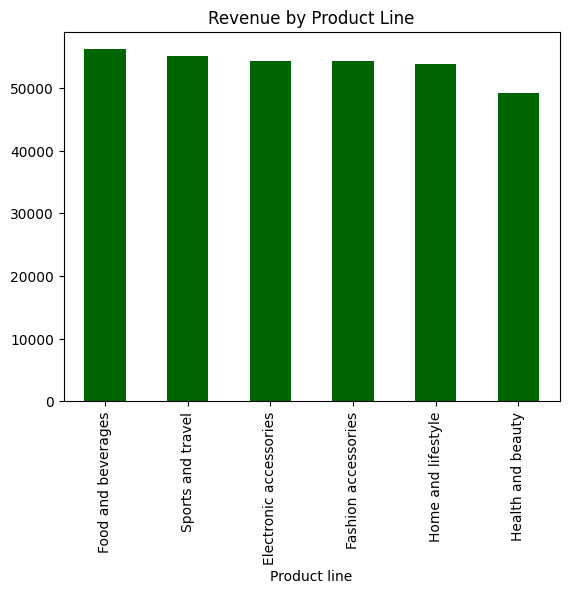

In [60]:
import matplotlib.pyplot as plt

sales_product.plot(kind="bar",color= 'darkgreen')
plt.title("Revenue by Product Line")
plt.show()

# Step 4 - EDA

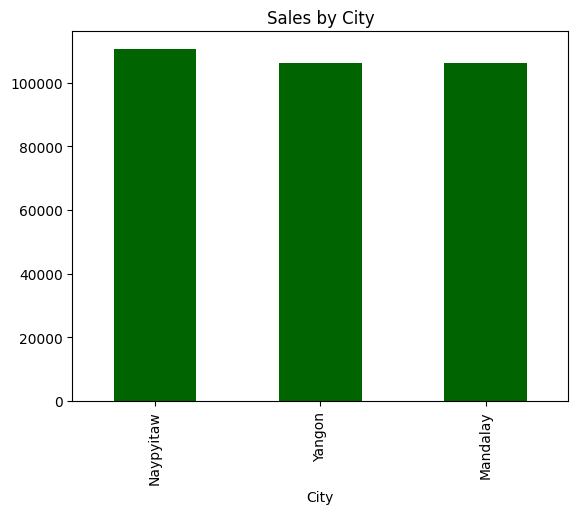

In [61]:
city_sales = df.groupby("City")['Sales'].sum().sort_values(ascending=False)
city_sales.plot(kind="bar",color= 'darkgreen')
plt.title("Sales by City")
plt.show()


# Step 5 - Explorary Analysis

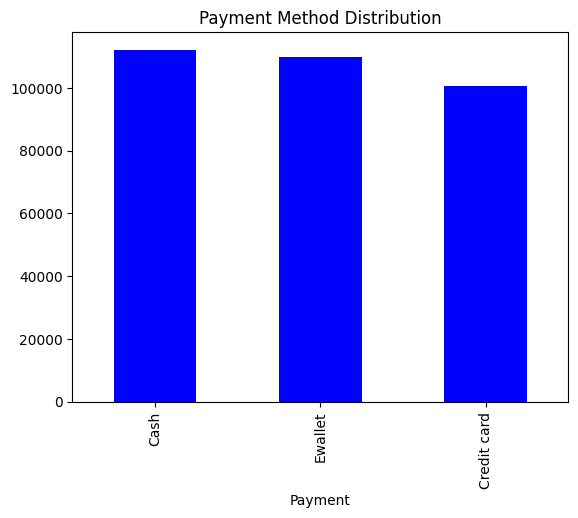

In [69]:
payment_method = df.groupby("Payment")['Sales'].sum().sort_values(ascending=False)
payment_method.plot(kind="bar",color= 'blue')
plt.title("Payment Method Distribution")
plt.show()

 Branch Performance

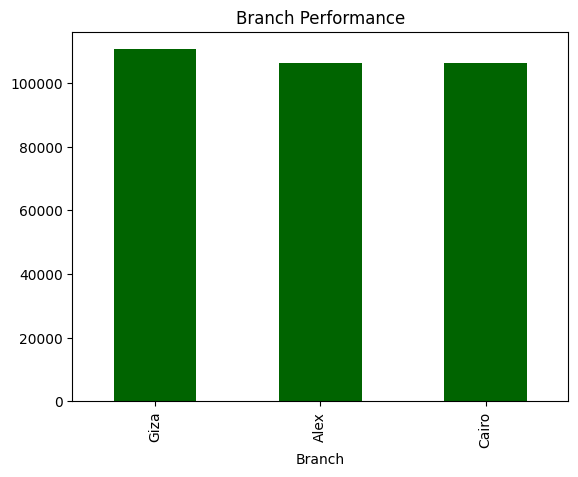

In [70]:
branch_sales = df.groupby("Branch")['Sales'].sum().sort_values(ascending=False)
branch_sales.plot(kind="bar",color= 'darkgreen')
plt.title("Branch Performance")
plt.show()

 Rating by Product Line

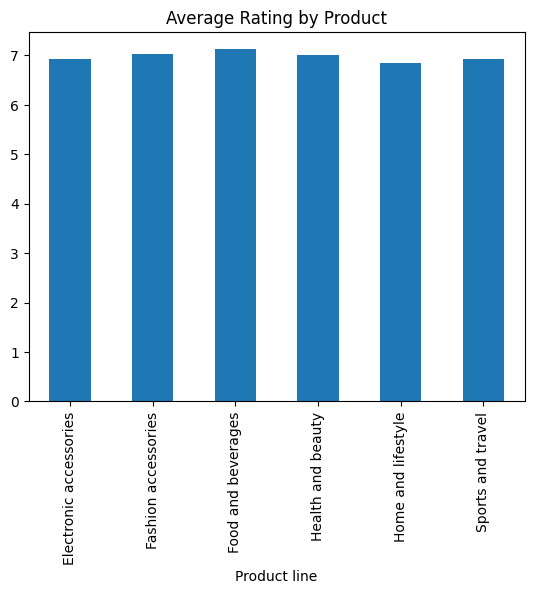

In [77]:
rating_product = df.groupby("Product line")["Rating"].mean()

rating_product.plot(kind="bar")
plt.title("Average Rating by Product")
plt.show()

Convert Date Column

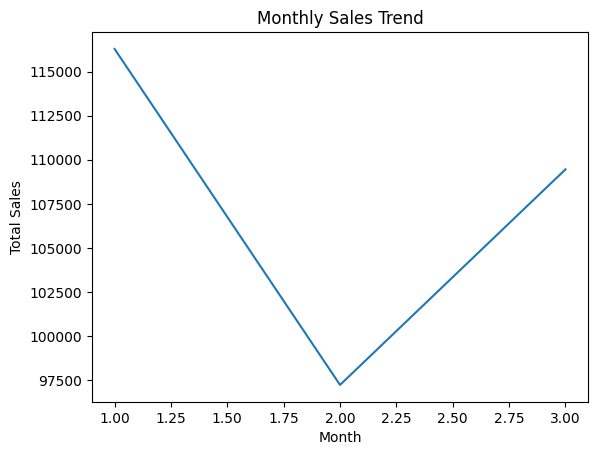

In [72]:
df["Date"] = pd.to_datetime(df["Date"])
monthly_sales = df.groupby(df["Date"].dt.month)["Sales"].sum()
plt.plot(monthly_sales.index, monthly_sales.values)
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.show()

At what time most sales happen?

In [73]:
df["Time"] = pd.to_datetime(df["Time"])
df["Hour"] = df["Time"].dt.hour

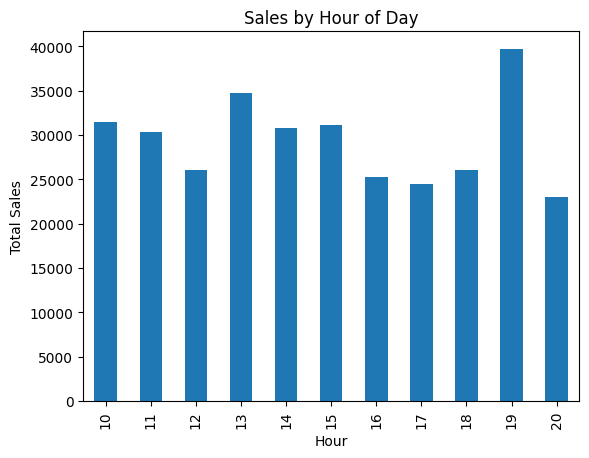

In [74]:
hourly_sales = df.groupby("Hour")["Sales"].sum()

hourly_sales.plot(kind="bar")
plt.title("Sales by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Total Sales")
plt.show()

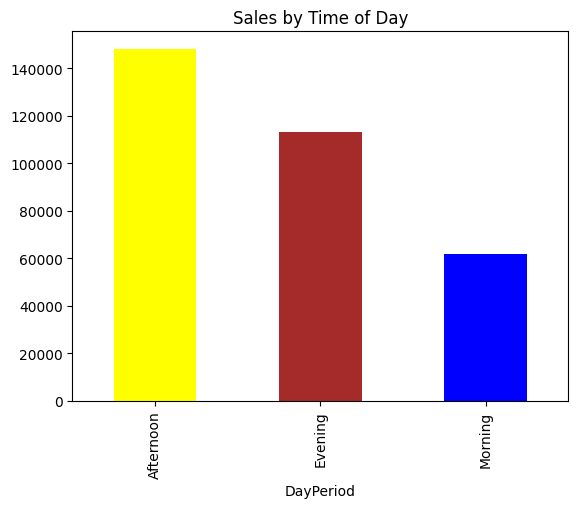

In [75]:
def time_of_day(hour):
    if hour < 12:
        return "Morning"
    elif hour < 17:
        return "Afternoon"
    else:
        return "Evening"

df["DayPeriod"] = df["Hour"].apply(time_of_day)

df.groupby("DayPeriod")["Sales"].sum().plot(kind="bar",color=["yellow","brown","blue"])
plt.title("Sales by Time of Day")
plt.show()

# Step 6 - Correlation Analysis

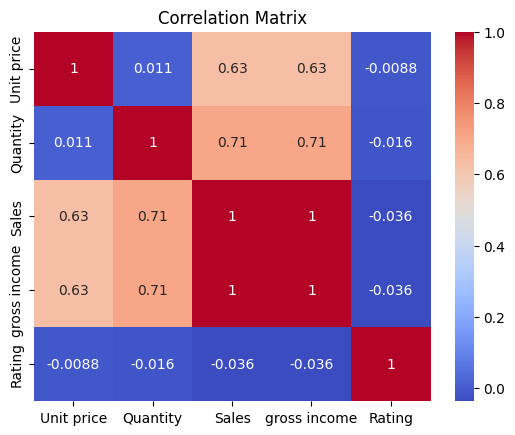

In [49]:
import seaborn as sns

numeric_cols = df[["Unit price","Quantity","Sales","gross income","Rating"]]

corr = numeric_cols.corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

The correlation matrix shows a very strong positive relationship between Sales and Gross Income. This is expected because gross income is calculated as a percentage of sales. Therefore, higher sales transactions naturally generate higher profit for the supermarket.

Sales by Gender

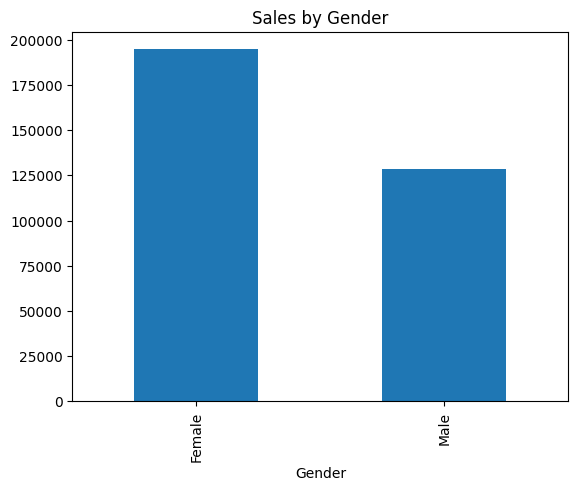

In [56]:
gender_sales = df.groupby("Gender")["Sales"].sum()

gender_sales.plot(kind="bar")
plt.title("Sales by Gender")
plt.show()

Average Spending of customer

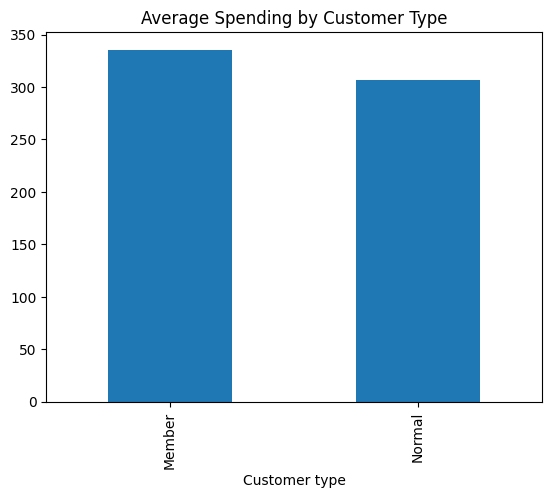

In [78]:
avg_spending = df.groupby("Customer type")["Sales"].mean()

avg_spending.plot(kind="bar")
plt.title("Average Spending by Customer Type")
plt.show()

Sales by Day of week


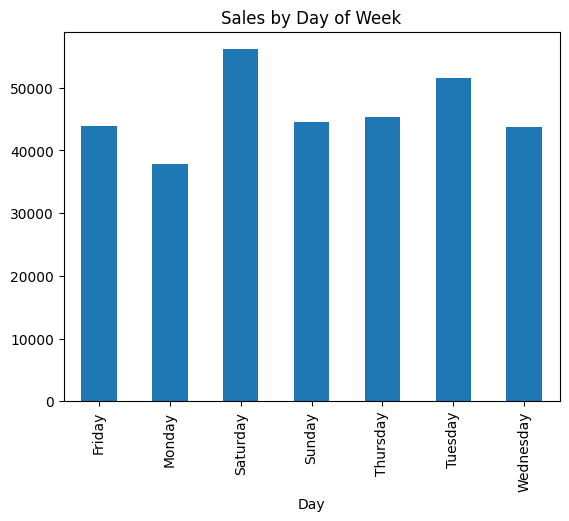

In [79]:
df["Date"] = pd.to_datetime(df["Date"])
df["Day"] = df["Date"].dt.day_name()

df.groupby("Day")["Sales"].sum().plot(kind="bar")
plt.title("Sales by Day of Week")
plt.show()

Profit by Product Line

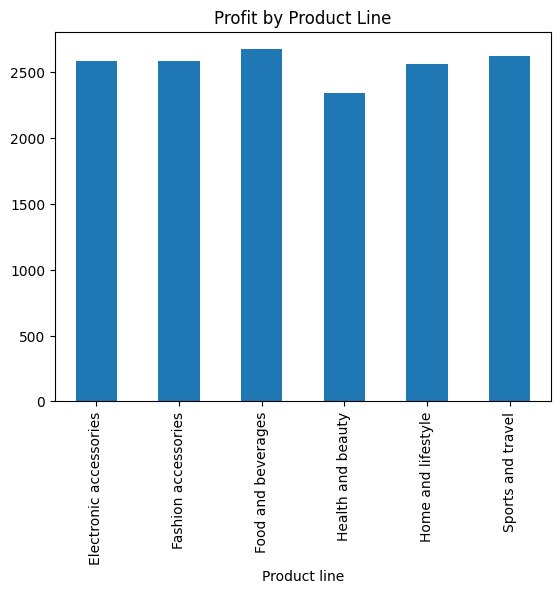

In [55]:
profit_product = df.groupby("Product line")["gross income"].sum()

profit_product.plot(kind="bar")
plt.title("Profit by Product Line")
plt.show()

# Step 7 - Business Insights


Afternoon hours generate the highest sales.

Food & Beverages produce the highest revenue.

Members spend more per transaction than non-members.

Cash is the most frequently used payment method.

Sales increase significantly on weekends particulary on Saturday

Females make more purchases than males.

